# Notebook 02: Cruise industry emissions

**Research context:** *Rethinking Vacations in an Era of Immobility*  
Data sources: Transport & Environment (2025); Friends of the Earth; Which? 2024 EU MRV study; ScienceDaily (2024); ICCT (2025); Cornell Hotel Sustainability Tool (2024).

This notebook visualizes the ecological cost of cruise tourism — per cruise line, per corporation, and in comparative context against other forms of travel and daily life. The data underpins the argument that what Blanco-Romero et al. (2023) call 'fake degrowth' — rebranding luxury tourism as sustainable — cannot address the biophysical violence embedded in the industry's operating logic.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
import plotly.express as px
from pathlib import Path

DATA = Path('../data')
FIGURES = Path('../figures')
FIGURES.mkdir(exist_ok=True)

BLUE = '#185FA5'
RED = '#E24B4A'
AMBER = '#BA7517'
GREEN = '#3B6D11'
GRAY = '#888780'
GRAY_LIGHT = '#D3D1C7'
TEXT = '#2C2C2A'
TEXT_SEC = '#5F5E5A'
BG = '#FAFAF8'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.grid': True,
    'axes.grid.axis': 'x',
    'grid.alpha': 0.4,
    'grid.linewidth': 0.5,
    'figure.facecolor': BG,
    'axes.facecolor': BG,
})
print('Setup complete.')

Setup complete.


In [8]:
df_lines = pd.read_csv(DATA / 'emissions_per_line.csv')
df_comp = pd.read_csv(DATA / 'emissions_comparative.csv')
print(df_lines.shape, df_comp.shape)
df_lines.sort_values('co2_per_nmi_kg', ascending=False)

(10, 5) (11, 5)


,cruise_line,parent_corp,co2_per_nmi_kg,data_source,year
0,Disney Cruise Line,Disney,1481,2024 EU MRV study,2023
1,Norwegian Cruise Line,NCL Holdings,1413,Transport & Environment EU MRV,2023
2,Princess Cruises,Carnival Corp,1253,Transport & Environment EU MRV,2023
3,Royal Caribbean Intl,Royal Caribbean Group,1248,Transport & Environment EU MRV,2023
4,MSC Cruises,MSC (independent),1050,EU MRV estimated average,2023
5,Carnival Cruise Line,Carnival Corp,980,EU MRV estimated average,2023
6,Costa Cruises,Carnival Corp,920,EU MRV estimated average,2023
7,AIDA Cruises,Carnival Corp,870,EU MRV estimated average,2023
8,Celebrity Cruises,Royal Caribbean Group,830,EU MRV estimated average,2023
9,Hurtigruten,Hurtigruten Group,210,ICCT verified,2023


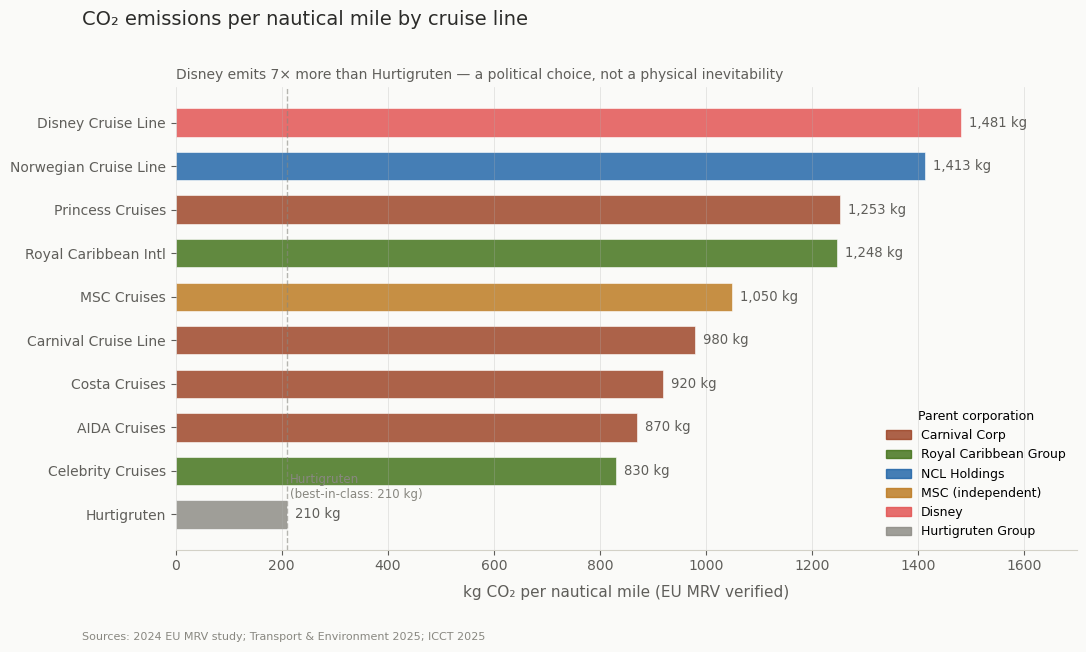

Saved: figures/fig_emissions_per_line.png


In [9]:
# --- Fig 2a: Horizontal bar — CO2 per nautical mile by cruise line ---
df_sorted = df_lines.sort_values('co2_per_nmi_kg', ascending=True)

# Color by parent corp
corp_colors = {
    'Carnival Corp': '#993C1D',
    'Royal Caribbean Group': GREEN,
    'NCL Holdings': BLUE,
    'MSC (independent)': AMBER,
    'Disney': RED,
    'Hurtigruten Group': GRAY,
}
bar_colors = [corp_colors.get(c, GRAY) for c in df_sorted.parent_corp]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(df_sorted.cruise_line, df_sorted.co2_per_nmi_kg,
               color=bar_colors, alpha=0.8, edgecolor='white', linewidth=0.5,
               height=0.65)

# Value labels
for bar, val in zip(bars, df_sorted.co2_per_nmi_kg):
    ax.text(val + 15, bar.get_y() + bar.get_height()/2,
            f'{val:,} kg', va='center', fontsize=9.5, color=TEXT_SEC)

# Reference line: Hurtigruten as best-in-class
ax.axvline(210, color=GRAY, lw=1, linestyle='--', alpha=0.6)
ax.text(215, 0.3, 'Hurtigruten\n(best-in-class: 210 kg)',
        fontsize=8.5, color=GRAY, va='bottom')

# Legend for parent corps
legend_items = [mpatches.Patch(color=c, alpha=0.8, label=k)
                for k, c in corp_colors.items()]
ax.legend(handles=legend_items, loc='lower right', frameon=False,
          fontsize=9, title='Parent corporation', title_fontsize=9)

ax.set_xlabel('kg CO₂ per nautical mile (EU MRV verified)', color=TEXT_SEC, labelpad=8)
ax.tick_params(colors=TEXT_SEC, labelsize=10)
ax.set_xlim(0, 1700)
ax.spines['bottom'].set_color(GRAY_LIGHT)

fig.suptitle('CO₂ emissions per nautical mile by cruise line',
             x=0.08, y=1.01, ha='left', fontsize=14, fontweight='500', color=TEXT)
ax.set_title('Disney emits 7× more than Hurtigruten — a political choice, not a physical inevitability',
             loc='left', fontsize=10, color=TEXT_SEC, pad=6)
fig.text(0.08, -0.04,
         'Sources: 2024 EU MRV study; Transport & Environment 2025; ICCT 2025',
         fontsize=8, color=GRAY, ha='left')

plt.tight_layout()
fig.savefig(FIGURES / 'fig_emissions_per_line.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: figures/fig_emissions_per_line.png')

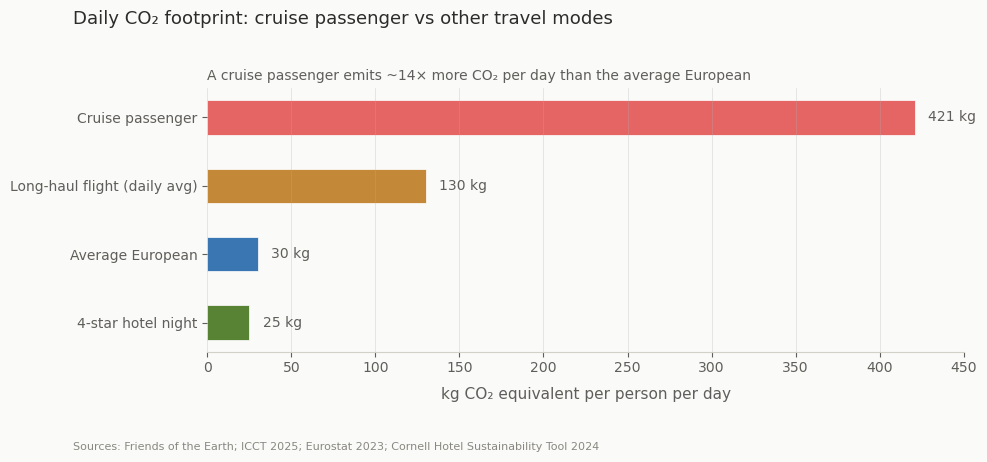

Saved: figures/fig_emissions_comparison.png


In [10]:
# --- Fig 2b: Comparative daily CO2 per person ---

df_daily = df_comp[df_comp.category == 'Daily kg CO2 per person'].copy()
df_daily = df_daily.sort_values('co2_value', ascending=True)

# Keep units in kg for clearer reading / storytelling
df_daily['co2_kg'] = df_daily['co2_value']

# Color patterns
bar_colors_daily = [
    RED if 'Cruise' in e else
    AMBER if 'flight' in e.lower() else
    BLUE if 'European' in e else
    GREEN
    for e in df_daily.entity
]

fig2, ax2 = plt.subplots(figsize=(10, 4))

bars2 = ax2.barh(
    df_daily.entity,
    df_daily.co2_kg,
    color=bar_colors_daily,
    alpha=0.85,
    edgecolor='white',
    linewidth=0.6,
    height=0.5
)

# Labels 
for bar, val in zip(bars2, df_daily.co2_kg):
    ax2.text(
        val + 8,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.0f} kg',
        va='center',
        fontsize=10,
        color=TEXT_SEC
    )

# Axis styling
ax2.set_xlabel(
    'kg CO₂ equivalent per person per day',
    color=TEXT_SEC,
    labelpad=8
)

ax2.tick_params(colors=TEXT_SEC, labelsize=10)

# FIXED SCALE with date in Kg
ax2.set_xlim(0, 450)

# Minimalist spines
for spine in ['top', 'right', 'left']:
    ax2.spines[spine].set_visible(False)

ax2.spines['bottom'].set_color(GRAY_LIGHT)

# Titles (refined hierarchy)
fig2.suptitle(
    'Daily CO₂ footprint: cruise passenger vs other travel modes',
    x=0.08,
    y=1.02,
    ha='left',
    fontsize=13,
    fontweight='500',
    color=TEXT
)

ax2.set_title(
    'A cruise passenger emits ~14× more CO₂ per day than the average European',
    loc='left',
    fontsize=10,
    color=TEXT_SEC,
    pad=6
)

# Source note
fig2.text(
    0.08,
    -0.08,
    'Sources: Friends of the Earth; ICCT 2025; Eurostat 2023; Cornell Hotel Sustainability Tool 2024',
    fontsize=8,
    color=GRAY,
    ha='left'
)

plt.tight_layout()
fig2.savefig(
    FIGURES / 'fig_emissions_comparison.png',
    dpi=300,
    bbox_inches='tight',
    facecolor=BG
)

plt.show()
print('Saved: figures/fig_emissions_comparison.png')

In [11]:
# --- Plotly interactive: emissions per line ---
df_sorted_desc = df_lines.sort_values('co2_per_nmi_kg', ascending=False)

fig_p = go.Figure(go.Bar(
    x=df_sorted_desc.cruise_line,
    y=df_sorted_desc.co2_per_nmi_kg,
    marker_color=[corp_colors.get(c, GRAY) for c in df_sorted_desc.parent_corp],
    marker_opacity=0.85,
    customdata=df_sorted_desc[['parent_corp', 'data_source']].values.tolist(),
    hovertemplate=('<b>%{x}</b><br>'
                   '%{y:,} kg CO₂/nmi<br>'
                   'Corp: %{customdata[0]}<br>'
                   'Source: %{customdata[1]}<extra></extra>')
))

fig_p.add_hline(y=210, line_dash='dash', line_color=GRAY, opacity=0.6,
                annotation_text='Hurtigruten best-in-class (210 kg)',
                annotation_position='top right',
                annotation_font_size=10, annotation_font_color=GRAY)

fig_p.update_layout(
    title='CO₂ emissions per nautical mile by cruise line (2023 EU MRV data)',
    yaxis_title='kg CO₂ per nautical mile',
    plot_bgcolor=BG, paper_bgcolor=BG, font_color=TEXT,
    margin=dict(t=70, b=80),
)
fig_p.update_yaxes(gridcolor=GRAY_LIGHT, gridwidth=0.5)
fig_p.update_xaxes(showgrid=False)

fig_p.write_html(FIGURES / 'fig_emissions.html')
fig_p.show()
print('Saved: figures/fig_emissions.html')

Saved: figures/fig_emissions.html
